# Table of Contents
- [Problem Definition](#intro)
- [Modules/Libraries](#modules)
- [Exploratory Data Analysis](#eda)
- [Data Cleanup](#cleanup)
- [NLP](#nlp)

## 👨🏻‍💻 Problem Definition <a id='intro'></a>

- This project analyzes sentiment in textual data using the VADER sentiment analysis tool. The text is preprocessed, including stemming, and classified into positive, neutral, or negative sentiments based on VADER's compound score thresholds. The sentiment distribution is visualized for training data. The project is a simple illustration of how an NLP technique can be used.

## ⚒️ Import data & modules <a id='modules'></a>
We will use some standard modules for data analysis, viz libraries, NLP tools.

In [1]:
# Standard Tools
import pandas as pd
import matplotlib.pyplot as plt

# NLP Tools
import re
import nltk
import string
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.stem import PorterStemmer
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm import tqdm

nltk.data.path.append('/Users/ipozdnyakov/nltk_data/tokenizers/punkt')  # Replace with your custom directory


In [2]:
# Necessary Resources from NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/ipozdnyakov/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ipozdnyakov/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/ipozdnyakov/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
# Progress Bar
tqdm.pandas()

## 🔮 Exploratory Data Analysis (EDA) <a id='eda'></a>
Let's take a first look at the data and try to infer some relationship between variables and decide if we need some additional cleanup.

The Amazon reviews polarity dataset is constructed by taking review score 1 and 2 as negative, and 4 and 5 as positive. Samples of score 3 is ignored. In the dataset, class 1 is the negative and class 2 is the positive. Each class has 1,800,000 training samples and 200,000 testing samples.

The files train.csv and test.csv contain all the training samples as comma-sparated values. There are 3 columns in them, corresponding to class index (1 or 2), review title and review text. The review title and text are escaped using double quotes ("), and any internal double quote is escaped by 2 double quotes (""). New lines are escaped by a backslash followed with an "n" character, that is "\n".

In [4]:
# Use Kaggle API to import the dataset
#path = kagglehub.dataset_download('kritanjalijain/amazon-reviews')
#print("Path to dataset files:", path)
path = '/Users/ipozdnyakov/.cache/kagglehub/datasets/kritanjalijain/amazon-reviews/versions/2'
column_names = ['class_index', 'review_title', 'review_text']
train_df = pd.read_csv(path + '/train.csv', header=None, names=column_names)
test_df = pd.read_csv(path + '/test.csv', header=None, names=column_names)

# Combine Datasets for Processing
train_df['source'] = 'train'
test_df['source'] = 'test'
df = pd.concat([train_df, test_df], ignore_index=True)

# Let's limit the working dataset to 1M rows
df = df[:1000000]

In [5]:
# Check for NAs in columns
print('Dataset Before Dropping NAs: \n', len(df))
print(df.isnull().sum())
df.dropna(inplace=True)
print('Dataset Length After Dropping NAs: ', len(df))

Dataset Before Dropping NAs: 
 1000000
class_index      0
review_title    66
review_text      0
source           0
dtype: int64
Dataset Length After Dropping NAs:  999934


In [6]:
# Check the structure of the Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999934 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   class_index   999934 non-null  int64 
 1   review_title  999934 non-null  object
 2   review_text   999934 non-null  object
 3   source        999934 non-null  object
dtypes: int64(1), object(3)
memory usage: 38.1+ MB


## 🧹 Data Cleanup <a id='cleanup'></a>
For every NLP project, it is imporant to make sure that the text data is as clean as possible. We will need to get rid of special characters, extract word stems, tokenize words. The cleaner the data, the better the results!

In [7]:
# Combine Review Title and Text for Processing
df['combined_text'] = df['review_title'] + " " + df['review_text']
df['combined_text'] = df['combined_text'].astype(str)

In [8]:
# Initialize the Porter stemmer and load English stopwords
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))
# Initialize RegexpTokenizer
tokenizer = RegexpTokenizer(r'\w+')  # Tokenizer that extracts words only

# Removing special characters and numbers
def clean_text(text):
    if isinstance(text, str):
        # Convert text to lowercase
        text = text.lower()

        # Remove URLs (http, https, and www links)
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

        # Remove markdown-style links [text](link)
        text = re.sub(r'\[.*?\]\(.*?\)', '', text)

        # Remove handles (@username mentions)
        text = re.sub(r'@\w+', '', text)

        # Remove punctuation and special characters
        text = text.translate(str.maketrans('', '', string.punctuation))

        # Remove numbers
        text = re.sub(r'\d+', '', text)

        return text
    else:
        return text

# Tokenize the text into individual words
def tokenize_text(text):
    if isinstance(text, str):
        return tokenizer.tokenize(text)
    else:
        return text

# Remove stopwords from the tokenized text
def remove_stopwords(tokens):
    if isinstance(tokens, list):
        return [word for word in tokens if word not in stop_words]
    else:
        return tokens

# Apply stemming to the tokens
def stem_tokens(tokens):
    if isinstance(tokens, list):
        return ' '.join(stemmer.stem(token) for token in tokens)
    else:
        return tokens

# Add progress bar for the cleaning process
tqdm.pandas()

# Clean the text
df['cleaned_text'] = df['combined_text'].progress_apply(clean_text)

# Tokenize the cleaned text
df['tokenized_text'] = df['cleaned_text'].progress_apply(tokenize_text)

# Remove stopwords from the tokenized text
df['no_stopwords_text'] = df['tokenized_text'].progress_apply(remove_stopwords)

# Apply stemming to the tokenized words
df['stemmed_text'] = df['no_stopwords_text'].progress_apply(stem_tokens)

# Drop unnecessary columns
df.drop(['cleaned_text', 'tokenized_text', 'no_stopwords_text'], axis=1, inplace=True)

100%|██████████| 999934/999934 [05:31<00:00, 3012.75it/s]


## 📖 NLP <a id='nlp'></a>
Once we've cleaned up the data, we can apply the Sentiment Analysis. For the purpose of this project, we're just looking at the train dataset as we're not intending to proceed with a full-fledged model here.

In [15]:
df.columns

Index(['class_index', 'review_title', 'review_text', 'source', 'combined_text',
       'stemmed_text', 'sentiment'],
      dtype='object')

In [ ]:
# Initialize SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Perform sentiment analysis
def get_sentiment(text):
    scores = sia.polarity_scores(text)
    if scores['compound'] >= 0.05:
        return 'positive'
    elif scores['compound'] <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['stemmed_text'].apply(get_sentiment)

# Separate train and test datasets
df_train = df[df['source'] == 'train']

# Display sentiment distribution
print("\nSentiment Distribution in Train Dataset:")
print(df_train['sentiment'].value_counts())



Sentiment Distribution in Train Dataset:
sentiment
positive    735646
negative    222233
neutral      42055
Name: count, dtype: int64

Sentiment Distribution in Test Dataset:
Series([], Name: count, dtype: int64)


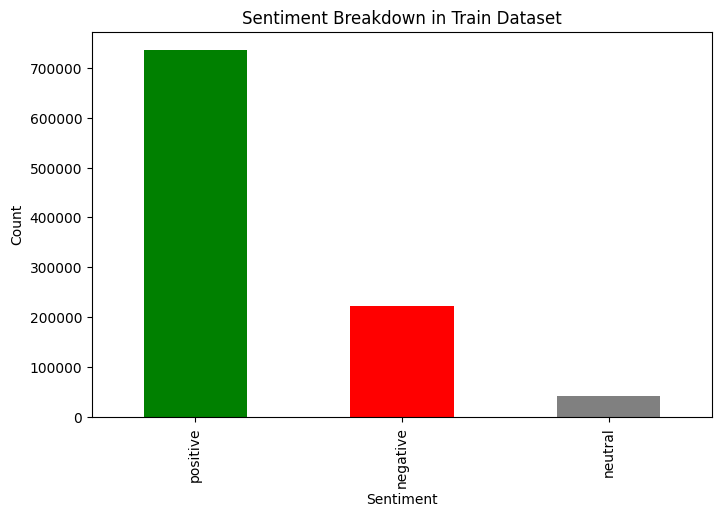

In [17]:
# Map sentiments to specific colors
color_map = {
    'positive': 'green',
    'neutral': 'grey',
    'negative': 'red'
}

# Get sentiment counts
sentiment_counts = df_train['sentiment'].value_counts()

# Plot with custom colors
sentiment_counts.plot(
    kind='bar',
    figsize=(8, 5),
    title="Sentiment Breakdown in Train Dataset",
    color=[color_map[sentiment] for sentiment in sentiment_counts.index]  # Map colors to index
)

plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


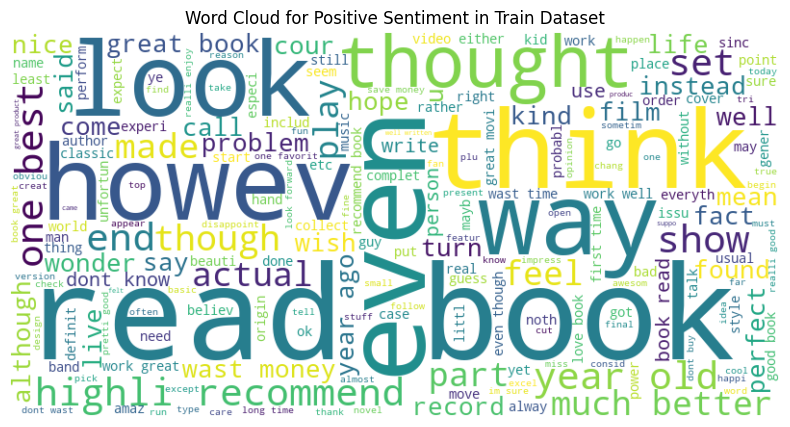

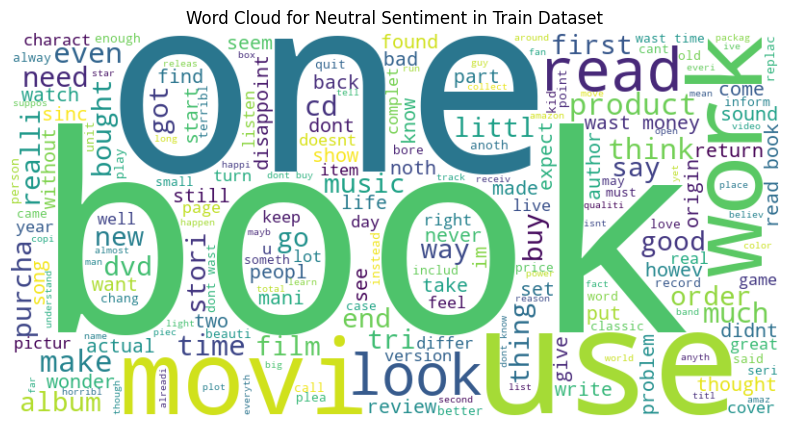

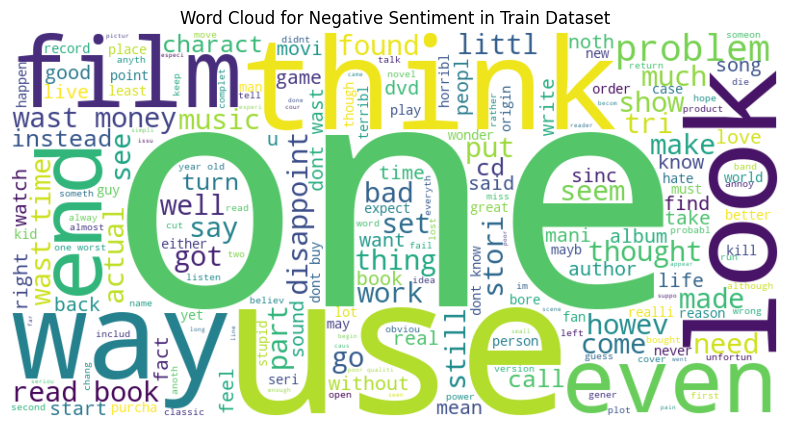

In [20]:
# Display word cloud for each sentiment in train and test datasets
for sentiment in ['positive', 'neutral', 'negative']:
    text = " ".join(df[df['sentiment'] == sentiment]['stemmed_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word Cloud for {sentiment.capitalize()} Sentiment in {label} Dataset")
    plt.show()